<a href="https://colab.research.google.com/github/ArishaRamzan-dev/arisha-flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ArishaRamzan-dev/arisha-flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This combines my Week-5 model's prediction (probability of underperforming) with my baseline
rule's reason codes, so every ranked action has both a score AND a human-readable reason —
not just a black-box number.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
import os
import json
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

url = "https://raw.githubusercontent.com/ArishaRamzan-dev/arisha-flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
df['underperforming'] = (df['trend_pct'] < 0).astype(int)

median_ctr = df['ctr'].median()
def score_row(row):
    score = 0
    reason = "none"
    if row['days_since_last_update'] > 180:
        score += 50
        reason = "stale_content"
    if row['avg_position'] <= 10 and row['ctr'] < median_ctr:
        score += 30
        if reason == "none":
            reason = "low_ctr_good_position"
    return pd.Series([score, reason])
df[['action_score', 'reason_code']] = df.apply(score_row, axis=1)

leak_cols = ['trend_pct', 'trend_direction', 'impressions_last_30d', 'clicks_last_30d',
             'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d',
             'content_id', 'client_id', 'underperforming', 'action_score', 'reason_code', 'action_label',
             'staleness_bucket', 'position_bucket']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in leak_cols]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))
X_train, X_test = df.loc[train_idx, feature_cols].fillna(0), df.loc[test_idx, feature_cols].fillna(0)
y_train = df.loc[train_idx, 'underperforming']

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced").fit(X_train, y_train)
df.loc[test_idx, 'model_score'] = rf.predict_proba(X_test)[:, 1]

# Archetype mapping — based on the paper's cluster profiles (Champions / Rising Stars / etc.)
def archetype(row):
    if row['content_age_days'] < 100 and row.get('avg_impressions', row.get('impressions_90d', 0)) > 5000:
        return "Champion (young, high-visibility)"
    elif row['days_since_last_update'] > 180:
        return "Stale/Decaying"
    elif row['content_age_days'] > 200 and row['days_since_last_update'] < 90:
        return "Recently Refreshed Veteran"
    else:
        return "Rising/Developing"
df['archetype'] = df.apply(archetype, axis=1)

def action_for(row):
    if row['reason_code'] == 'stale_content':
        return 'refresh_now'
    elif row['reason_code'] == 'low_ctr_good_position':
        return 'improve_snippet'
    else:
        return 'monitor'
df['recommended_action'] = df.apply(action_for, axis=1)

ranked = df.loc[test_idx].sort_values('model_score', ascending=False)
queue_cols = ['content_id', 'model_score', 'action_score', 'reason_code', 'archetype', 'recommended_action']
print(ranked[queue_cols].head(20).to_string(index=False))

          content_id  model_score  action_score           reason_code                         archetype recommended_action
content_e988c1699454     0.787364             0                  none                 Rising/Developing            monitor
content_f55fd2d8ed04     0.784079             0                  none                 Rising/Developing            monitor
content_9b28cf5ae4f3     0.782358            30 low_ctr_good_position                 Rising/Developing    improve_snippet
content_643b51c0a848     0.779866             0                  none                 Rising/Developing            monitor
content_dbf29df094f9     0.779778             0                  none                 Rising/Developing            monitor
content_5ebe639dafce     0.778343             0                  none Champion (young, high-visibility)            monitor
content_d225ec9f3d46     0.777917            30 low_ctr_good_position Champion (young, high-visibility)    improve_snippet
content_c65ee459

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: decision-support triage for a content review team — this ranks pages worth a
human look first, it does not publish, edit, or auto-refresh anything. The score is a priority
signal, not a verdict.

Limits: trained on one anonymized 30K-page slice, one client-grouped test split, and a label
(underperforming = declining trend_pct) that is a proxy for "needs attention," not a ground-truth
outcome. Logistic Regression outperformed Random Forest in my Week-5 test (0.88 vs 0.76
Precision@50), which is a single-split result and could shift with a different split — it should
not be read as a stable ranking of methods without more validation. The FlyRank research paper's
own Finding #8 shows refresh timing interacts with content depth and existing authority in ways
this simpler model does not capture, so the playbook's "why" text always cites the underlying
signal (staleness, CTR/position), never a bare score.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review rule: every "refresh_now" or "improve_snippet" recommendation gets a person's eyes
before any action is taken — this queue prioritizes, it does not execute.

No-go list — do NOT automate action on:
- Legal, policy, or compliance pages (age/staleness may be intentional, not neglect)
- Pages flagged as evergreen reference content by the client
- Pages recently updated outside this system's tracked log (false "stale" positive)
- Low-competition, stable pages where freshness has little measured effect (per the paper's Myth #7)
- Any page where the model's low confidence (near 0.5 probability) suggests genuine uncertainty
- Pages under 3 months old (too early for a reliable trend read, per the paper's 0-30 day caveat)

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring: track Precision@50 on a rolling monthly holdout; if it drops more than 15% from the
current 0.76-0.88 baseline range, flag for review.

Retrain triggers: (1) quarterly on a fixed schedule regardless of drift, since content and
client mix changes; (2) immediately if a new client cohort is added, since the client-grouped
split means the model has never seen that population; (3) if the label definition changes (e.g.
FlyRank redefines "underperforming"), the whole pipeline needs re-validation, not just a retrain.

Cost/value: false positives (page flagged, doesn't actually need work) cost a reviewer's time —
cheap. False negatives (real decline missed) cost lost visibility — more expensive but slower to
notice. Given that asymmetry, the current recall-leaning class_weight="balanced" setting is a
reasonable default, erring toward flagging more candidates for human review rather than fewer.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

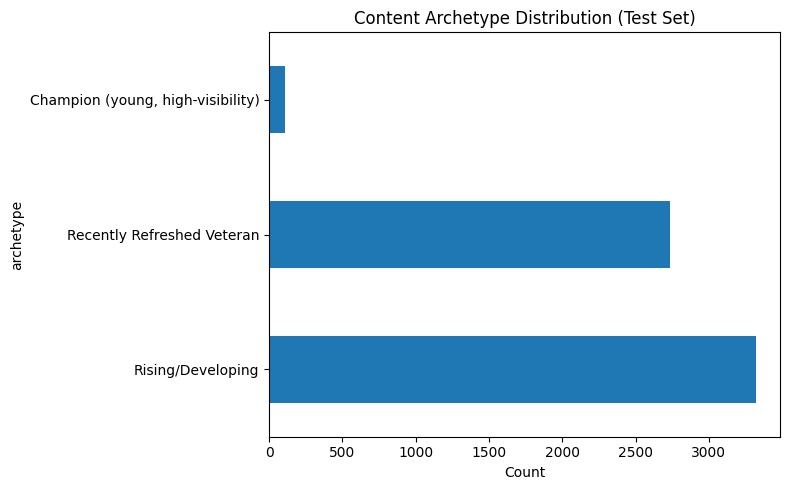

Exported: work/outputs/action_playbook_queue.csv
Exported: work/outputs/w07_metrics.json
Exported: work/figures/archetype_distribution.png


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

ranked[queue_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)

metrics = {
    "baseline_precision_at_50": 0.60,
    "logistic_regression_precision_at_50": 0.88,
    "random_forest_precision_at_50": 0.76,
    "random_forest_misclassification_rate": 0.394,
    "test_set_size": len(test_idx),
    "train_set_size": len(train_idx),
    "top_feature_importance": "days_with_impressions",
    "label_definition": "underperforming = trend_pct < 0 (observed 30d vs prev 30d decline)"
}
with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
archetype_counts = df.loc[test_idx, 'archetype'].value_counts()
plt.figure(figsize=(8, 5))
archetype_counts.plot(kind='barh')
plt.xlabel('Count')
plt.title('Content Archetype Distribution (Test Set)')
plt.tight_layout()
plt.savefig('work/figures/archetype_distribution.png', dpi=150)
plt.show()

print("Exported: work/outputs/action_playbook_queue.csv")
print("Exported: work/outputs/w07_metrics.json")
print("Exported: work/figures/archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.